# Single CatBoost — Self-Contained Standalone — LendingClub Interest Rate Prediction

**Runs with only `true data/LC_train.csv` present.** If `true data/LC_test.csv` also
exists, the notebook additionally writes the final test submission.

**Outputs** (the final CSV plus all diagnostic/explainability artifacts) are written to a
root-level **`final-submission-output/`** folder.

**Part 1 — Single CatBoost.** Loads + engineers features, builds target-encoded CatBoost
frames, fits one CatBoost early-stopped on a 20% holdout, reports held-out RMSE / MAE / R2,
and writes the submission CSV.

**Part 2 — Diagnostic suite (live).** Per-round learning curve, data-size learning curve,
and an OOF-vs-val residual overlay.

**Part 3 — Explainability (live).** Permutation importance, CatBoost gain, SHAP
summary/dependence, PDP/ICE, SHAP waterfall, LIME, and cross-split SHAP.

**Anti-leakage**: `loan_status` dropped at load; random 80/20 holdout (no date columns in
this slice); K-fold OOF smoothed target encoding fit on training folds only.


---
# Part 1 — Single CatBoost

## 1. Imports + config + inlined helpers

Everything the notebook needs (paths, constants, hardcoded CatBoost params, and the
`load_raw` / `engineer` / target-encoding / CatBoost-frame helpers) is defined here, so no
other project file is required.

In [27]:
# !pip install catboost

In [28]:
from pathlib import Path


def find_data_file(filename, start=None, max_up=6, extra_subdirs=None):
    """Locate `filename` no matter where it lives relative to the run location.

    Search order, repeated while walking UP the directory tree from `start`:
      1. the directory itself
      2. a set of common data subfolders inside it
      3. a full recursive glob as a last resort at each level

    Parameters
    ----------
    filename : str
        File to find, e.g. 'LC_train.csv'.
    start : str | Path | None
        Where to begin searching. Defaults to the current working directory.
    max_up : int
        How many parent levels to climb before giving up.
    extra_subdirs : list[str] | None
        Additional subfolder names to check at each level.

    Returns
    -------
    Path to the located file.

    Raises
    ------
    FileNotFoundError if the file cannot be found within the search budget.
    """
    start = Path(start).resolve() if start is not None else Path.cwd().resolve()

    subdirs = ['true data', 'data', 'datasets', 'input', 'raw', 'final/true data']
    if extra_subdirs:
        subdirs = list(extra_subdirs) + subdirs

    current = start
    for _ in range(max_up + 1):
        # 1. directly in this directory
        candidate = current / filename
        if candidate.is_file():
            return candidate

        # 2. common data subfolders
        for sub in subdirs:
            candidate = current / sub / filename
            if candidate.is_file():
                return candidate

        # 3. recursive search under this directory (cheap fallback)
        matches = list(current.glob(f'**/{filename}'))
        if matches:
            # prefer the shallowest match for determinism
            return min(matches, key=lambda p: len(p.parts))

        if current.parent == current:  # reached filesystem root
            break
        current = current.parent

    raise FileNotFoundError(
        f"Could not find {filename!r} starting from {start} "
        f"(searched {max_up} levels up, common subfolders, and recursively)."
    )

In [29]:
from pathlib import Path
import json, warnings
from time import time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, train_test_split, learning_curve

# --------------------------------------------------------------------------------------
# Paths — locate the data files wherever they live.
# --------------------------------------------------------------------------------------
TRAIN_PATH = find_data_file('LC_train.csv')
DATA_DIR = TRAIN_PATH.parent
PROJECT_ROOT = DATA_DIR.parent
OUT_DIR = PROJECT_ROOT / 'final-submission-output'
OUT_DIR.mkdir(parents=True, exist_ok=True)


def load_raw():
    dtype_overrides = {c: 'float64' for c in STRING_NUMERIC_COLS}
    train = pd.read_csv(TRAIN_PATH, na_values=['NA'], dtype=dtype_overrides)
    train = train.drop(columns=['loan_status'])

    test = None
    try:
        test_path = find_data_file('LC_test.csv', start=DATA_DIR)
        test = pd.read_csv(test_path, na_values=['NA'], dtype=dtype_overrides)
        test = test.drop(columns=['loan_status'])
    except FileNotFoundError:
        pass  # test file is optional

    return train, test
# --------------------------------------------------------------------------------------
# Constants
# --------------------------------------------------------------------------------------
RANDOM_STATE = 6604
N_FOLDS = 5
TARGET_ENC_M = 20.0
EMP_TITLE_TOP_N = 100
HOLDOUT_FRAC = 0.20

# Cached CatBoost hyperparameters (from the SOTA Optuna run — hardcoded so no JSON is needed).
CB_PARAMS = {
    'learning_rate': 0.03,
    'depth': 7,
    'l2_leaf_reg': 5.0,
    'random_strength': 1.0,
    'bagging_temperature': 0.5,
    'border_count': 200,
}

EMP_LENGTH_MAP = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9,
    '10+ years': 10,
}
MTHS_SINCE_COLS = [
    'mths_since_last_record', 'mths_since_recent_inq',
    'mths_since_rcnt_il', 'mths_since_recent_bc',
]
LOG_NUMERIC_COLS = [
    'annual_inc', 'revol_bal', 'tot_cur_bal', 'total_bal_ex_mort', 'tot_coll_amt',
]
STRING_NUMERIC_COLS = [
    'dti', 'revol_util', 'all_util', 'mo_sin_old_il_acct', 'mths_since_last_record',
    'mths_since_rcnt_il', 'mths_since_recent_bc', 'mths_since_recent_inq', 'tot_cur_bal',
]
NATIVE_CAT_COLS = ['application_type', 'home_ownership', 'verification_status', 'purpose']
TE_CAT_COLS = ['addr_state', 'purpose', 'zip3', 'emp_title']
ALL_CAT_COLS = list(set(NATIVE_CAT_COLS + TE_CAT_COLS))


# --------------------------------------------------------------------------------------
# Load — only LC_train.csv is required; LC_test.csv is used if it exists.
# --------------------------------------------------------------------------------------
def load_raw():
    dtype_overrides = {c: 'float64' for c in STRING_NUMERIC_COLS}
    train = pd.read_csv(DATA_DIR / 'LC_train.csv', na_values=['NA'], dtype=dtype_overrides)
    train = train.drop(columns=['loan_status'])
    test_path = DATA_DIR / 'LC_test.csv'
    test = None
    if test_path.exists():
        test = pd.read_csv(test_path, na_values=['NA'], dtype=dtype_overrides)
        test = test.drop(columns=['loan_status'])
    return train, test


# --------------------------------------------------------------------------------------
# Stateless feature engineering (no fit — safe to apply to any frame)
# --------------------------------------------------------------------------------------
def engineer(df):
    out = df.copy()
    out['fico'] = (out['fico_range_low'] + out['fico_range_high']) / 2
    out['term_months'] = out['term'].astype('string').str.extract(r'(\d+)', expand=False).astype('Int64')
    out['emp_length_num'] = out['emp_length'].map(EMP_LENGTH_MAP)
    for c in MTHS_SINCE_COLS:
        out['has_' + c] = out[c].notna().astype(int)
    out['loan_to_income'] = out['loan_amnt'] / out['annual_inc'].replace(0, np.nan)
    out['installment_proxy'] = out['loan_amnt'] / out['term_months'].astype('float64')
    out['bal_to_income'] = out['tot_cur_bal'] / out['annual_inc'].replace(0, np.nan)
    out['util_x_fico'] = out['revol_util'] * out['fico']
    out['dti_x_fico'] = out['dti'] * out['fico']
    out['acc_open_ratio'] = out['open_acc'] / out['total_acc'].replace(0, np.nan)
    out['dti_band'] = pd.cut(out['dti'], bins=[-np.inf, 10, 20, 30, 40, np.inf], labels=False).astype('Int64')
    out['fico_band'] = pd.cut(out['fico'], bins=[-np.inf, 660, 680, 700, 720, 740, 760, 780, np.inf], labels=False).astype('Int64')
    out['fico_x_term'] = out['fico'] * out['term_months'].astype('float64')
    out['fico_x_dti_band'] = out['fico'] * out['dti_band'].astype('float64')
    out['derog_score'] = (
        out['delinq_2yrs'].fillna(0) * 8
        + out['pub_rec'].fillna(0) * 13
        + out['pub_rec_bankruptcies'].fillna(0) * 22
        + out['chargeoff_within_12_mths'].fillna(0) * 15
        + out['collections_12_mths_ex_med'].fillna(0) * 10
    )
    out['inq_intensity'] = out['inq_last_12m'].fillna(0) + out['inq_fi'].fillna(0)
    out['revol_util_band'] = pd.cut(out['revol_util'], bins=[-np.inf, 30, 50, 75, 100, np.inf], labels=False).astype('Int64')
    out['all_util_band'] = pd.cut(out['all_util'], bins=[-np.inf, 30, 50, 75, 100, np.inf], labels=False).astype('Int64')
    out['credit_file_age_yrs'] = out['mo_sin_old_rev_tl_op'] / 12.0
    out['term_x_loan_amnt'] = out['term_months'].astype('float64') * out['loan_amnt']
    out['term_x_dti'] = out['term_months'].astype('float64') * out['dti']
    out['payment_to_income'] = (
        out['loan_amnt'] / out['term_months'].astype('float64')
    ) / (out['annual_inc'].replace(0, np.nan) / 12.0)
    for c in LOG_NUMERIC_COLS:
        out['log1p_' + c] = np.log1p(out[c].clip(lower=0))
    out['zip3'] = out['zip_code'].astype('string').str.extract(r'(\d{3})', expand=False)
    if 'emp_title' in out.columns:
        out['emp_title'] = out['emp_title'].astype('string').str.lower().str.strip()
    out['fico_range_width'] = (out['fico_range_high'] - out['fico_range_low']).astype('float64')
    drop = ['fico_range_low', 'fico_range_high', 'term', 'emp_length', 'title', 'zip_code']
    return out.drop(columns=[c for c in drop if c in out.columns])


# --------------------------------------------------------------------------------------
# Smoothed out-of-fold K-fold target encoding (no leakage). Xva / Xte are optional.
# --------------------------------------------------------------------------------------
def smoothed_target_encode(train_col, target, val_col=None, test_col=None,
                           m=TARGET_ENC_M, folds=5, seed=RANDOM_STATE):
    global_mean = float(np.nanmean(target))
    val_enc = test_enc = None
    if val_col is not None or test_col is not None:
        full = pd.DataFrame({'cat': train_col.values, 'y': target})
        stats = full.groupby('cat')['y'].agg(['mean', 'count'])
        stats['enc'] = (stats['mean'] * stats['count'] + global_mean * m) / (stats['count'] + m)
        mapping = stats['enc'].to_dict()
        val_enc = val_col.map(mapping).fillna(global_mean).values if val_col is not None else None
        test_enc = test_col.map(mapping).fillna(global_mean).values if test_col is not None else None
    train_enc = np.full(len(train_col), global_mean, dtype=np.float64)
    kf = KFold(n_splits=folds, shuffle=True, random_state=seed)
    for tr, va in kf.split(train_col):
        inner = pd.DataFrame({'cat': train_col.values[tr], 'y': target[tr]})
        stats = inner.groupby('cat')['y'].agg(['mean', 'count'])
        stats['enc'] = (stats['mean'] * stats['count'] + global_mean * m) / (stats['count'] + m)
        mapping = stats['enc'].to_dict()
        train_enc[va] = pd.Series(train_col.values[va]).map(mapping).fillna(global_mean).values
    return train_enc, val_enc, test_enc


def add_target_encodings(Xtr, ytr, Xva=None, Xte=None):
    Xtr = Xtr.copy()
    Xva = Xva.copy() if Xva is not None else None
    Xte = Xte.copy() if Xte is not None else None
    for c in TE_CAT_COLS:
        if c not in Xtr.columns:
            continue
        tr_e, va_e, te_e = smoothed_target_encode(
            Xtr[c].astype(str), ytr,
            Xva[c].astype(str) if Xva is not None else None,
            Xte[c].astype(str) if Xte is not None else None,
        )
        Xtr[c + '_te'] = tr_e
        if Xva is not None:
            Xva[c + '_te'] = va_e
        if Xte is not None:
            Xte[c + '_te'] = te_e
    return Xtr, Xva, Xte


# --------------------------------------------------------------------------------------
# CatBoost frame prep: native categoricals as strings, everything else float.
# --------------------------------------------------------------------------------------
def to_catboost_pool(X):
    X = X.copy()
    cat_cols = [c for c in ALL_CAT_COLS if c in X.columns]
    for c in cat_cols:
        X[c] = X[c].astype('string').fillna('Missing')
    cat_idx = [X.columns.get_loc(c) for c in cat_cols]
    for c in X.columns:
        if c not in cat_cols:
            X[c] = X[c].astype('float64')
    return X, cat_idx


print('Self-contained helpers loaded.')
print('Project root:', PROJECT_ROOT)
print('Data dir    :', DATA_DIR)
print('Outputs dir :', OUT_DIR)


Self-contained helpers loaded.
Project root: C:\Users\liula\Documents\applied ai\project 1
Data dir    : C:\Users\liula\Documents\applied ai\project 1\true data
Outputs dir : C:\Users\liula\Documents\applied ai\project 1\final-submission-output


## 2. Load + drop leakage column

`loan_status` is a post-origination outcome and would leak future information into a rate
model, so it is dropped on load. Only `LC_train.csv` is required; `LC_test.csv` is loaded
only if it is present.

In [30]:
train_raw, test_raw = load_raw()
HAS_TEST = test_raw is not None
print('train:', train_raw.shape, '   test:', (test_raw.shape if HAS_TEST else 'NOT PRESENT (train-only run)'))
print('target stats:')
print(train_raw['int_rate'].describe().round(3))


train: (100000, 38)    test: (10000, 38)
target stats:
count    100000.000
mean         12.947
std           5.256
min           6.460
25%           8.190
50%          11.710
75%          16.120
max          30.990
Name: int_rate, dtype: float64


## 3. Feature engineering

Stateless transforms only (FICO midpoint + band, term, underwriting ratios, interactions,
log-tails, `zip3`, missingness flags). Anything that needs a fit (target encoding) happens
inside the K-fold loop / on the train fold only.

In [31]:
train_fe = engineer(train_raw)
test_fe = engineer(test_raw) if HAS_TEST else None

# Top-N emp_title compaction (fit on TRAIN only).
top = train_fe['emp_title'].value_counts().head(EMP_TITLE_TOP_N).index.tolist()
train_fe['emp_title'] = train_fe['emp_title'].where(train_fe['emp_title'].isin(top), 'Other').fillna('Missing').astype(str)

if HAS_TEST:
    test_fe['emp_title'] = test_fe['emp_title'].where(test_fe['emp_title'].isin(top), 'Other').fillna('Missing').astype(str)
    test_ids = test_fe['ID'].copy()
    test_fe = test_fe.drop(columns=['ID'])
else:
    test_ids = None

y_full = train_fe['int_rate'].values.astype(np.float64)
X_full = train_fe.drop(columns=['int_rate'])
print('engineered cols:', X_full.shape[1])
print(list(X_full.columns))


engineered cols: 63
['addr_state', 'all_util', 'annual_inc', 'application_type', 'chargeoff_within_12_mths', 'collections_12_mths_ex_med', 'delinq_2yrs', 'dti', 'emp_title', 'home_ownership', 'inq_fi', 'inq_last_12m', 'loan_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mort_acc', 'mths_since_last_record', 'mths_since_rcnt_il', 'mths_since_recent_bc', 'mths_since_recent_inq', 'open_acc', 'pub_rec', 'pub_rec_bankruptcies', 'purpose', 'revol_bal', 'revol_util', 'tot_coll_amt', 'tot_cur_bal', 'total_acc', 'total_bal_ex_mort', 'verification_status', 'fico', 'term_months', 'emp_length_num', 'has_mths_since_last_record', 'has_mths_since_recent_inq', 'has_mths_since_rcnt_il', 'has_mths_since_recent_bc', 'loan_to_income', 'installment_proxy', 'bal_to_income', 'util_x_fico', 'dti_x_fico', 'acc_open_ratio', 'dti_band', 'fico_band', 'fico_x_term', 'fico_x_dti_band', 'derog_score', 'inq_intensity', 'revol_util_band', 'all_util_band', 'credit_file_age_yrs', 'term_x_loan_amnt', 'term_x_dti', 

## New interaction terms — rationale

LendingClub does not price `int_rate` as a smooth linear function of any single field; it
prices it off discrete credit tiers and the *joint* interaction of creditworthiness with
loan terms and debt burden. The engineered terms below give the trees clean, low-noise
splits that mirror how that pricing actually works.

**`fico_band` (finer 8-tier split).** Lender pricing moves in discrete credit-score
brackets, not linearly. The 8-tier split (`660/680/700/720/740/760/780`) aligns bucket
edges with the 20-point bands where lenders typically re-price.

**`fico_x_term` (FICO × term length).** Rate is set jointly on creditworthiness and loan
tenor: at any given FICO, a 60-month loan carries a higher rate than a 36-month one.

**`fico_range_width` (width of the reported FICO band).** The width of the reported FICO
range reflects how the score was pulled and the underwriting uncertainty around the
borrower — preserved before the raw pair is dropped.

**`fico_x_dti_band` (FICO × debt-burden tier).** The same FICO is priced differently
depending on how leveraged the borrower already is; this term gives the model a direct
handle on the joint credit-quality × debt-burden effect.

## 4. 80/20 holdout split

Fixed-seed random split — no date columns exist in this slice, so a temporal split is
impossible.

In [32]:
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=HOLDOUT_FRAC, random_state=RANDOM_STATE,
)
X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
print('X_train:', X_train.shape, '  X_val:', X_val.shape,
      '  X_test:', (test_fe.shape if HAS_TEST else 'n/a'))


X_train: (80000, 63)   X_val: (20000, 63)   X_test: (10000, 63)


## 5. CatBoost hyperparameters

Hardcoded from the cached SOTA Optuna run (no `tuning_results.json` needed).

In [33]:
print('[CatBoost]', CB_PARAMS)


[CatBoost] {'learning_rate': 0.03, 'depth': 7, 'l2_leaf_reg': 5.0, 'random_strength': 1.0, 'bagging_temperature': 0.5, 'border_count': 200}


## 6. Build target-encoded CatBoost frames

Smoothed K-fold target encoding is fit on the **train fold only** (`X_train` / `y_train`)
and applied to val (and test, if present), then every frame is converted to the CatBoost
layout (native categoricals as strings, everything else float).

In [34]:
from catboost import CatBoostRegressor, Pool

Xtr_te_full, Xval_te_full, Xte_te_full = add_target_encodings(X_train, y_train, X_val, test_fe)
Xtr_cb_full, cat_idx_full = to_catboost_pool(Xtr_te_full)
Xval_cb_full, _ = to_catboost_pool(Xval_te_full)
Xte_cb_full = to_catboost_pool(Xte_te_full)[0] if HAS_TEST else None
print('full-train CB frame:', Xtr_cb_full.shape)
print('categorical cols   :', [Xtr_cb_full.columns[i] for i in cat_idx_full])


full-train CB frame: (80000, 67)
categorical cols   : ['emp_title', 'addr_state', 'verification_status', 'zip3', 'application_type', 'home_ownership', 'purpose']


## 7. Train the single CatBoost (early-stopped on the holdout)

In [35]:
CB_ITERS = 2500

explain_model = CatBoostRegressor(**CB_PARAMS, iterations=CB_ITERS,
                                  loss_function='RMSE', eval_metric='RMSE',
                                  random_seed=RANDOM_STATE, verbose=0,
                                  allow_writing_files=False, early_stopping_rounds=100)
t = time()
explain_model.fit(Xtr_cb_full, y_train, cat_features=cat_idx_full,
                  eval_set=(Xval_cb_full, y_val), verbose=False)
val_pred = explain_model.predict(Xval_cb_full)
test_pred = explain_model.predict(Xte_cb_full) if HAS_TEST else None
print('CatBoost trained: %d trees  (%.0fs)' % (explain_model.tree_count_, time() - t))


CatBoost trained: 2500 trees  (571s)


## 8. Held-out validation metrics

In [36]:
val_rmse = float(np.sqrt(mean_squared_error(y_val, val_pred)))
val_mae  = float(mean_absolute_error(y_val, val_pred))
val_r2   = float(r2_score(y_val, val_pred))
res_df = pd.DataFrame([{'model': 'CatBoost', 'val_RMSE': val_rmse,
                        'val_MAE': val_mae, 'val_R2': val_r2}])
display(res_df.style.format({'val_RMSE': '{:.4f}', 'val_MAE': '{:.4f}', 'val_R2': '{:.4f}'}))
res_df.to_csv(OUT_DIR / 'catboost_results.csv', index=False)
print('val RMSE: %.4f   val MAE: %.4f   val R2: %.4f' % (val_rmse, val_mae, val_r2))


,model,val_RMSE,val_MAE,val_R2
0,CatBoost,3.8698,2.9009,0.4654


val RMSE: 3.8698   val MAE: 2.9009   val R2: 0.4654


## 9. Residual diagnostics

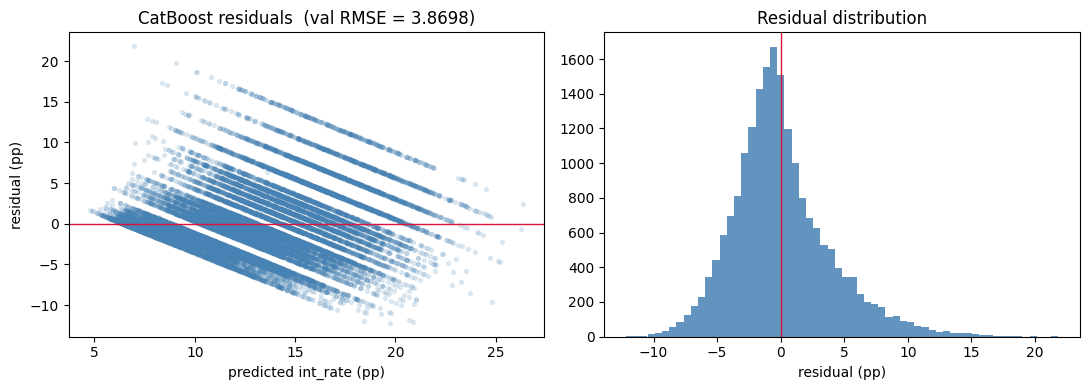

In [37]:
resid = y_val - val_pred

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(val_pred, resid, alpha=0.15, s=8, color='steelblue')
axes[0].axhline(0, color='crimson', lw=1)
axes[0].set_xlabel('predicted int_rate (pp)')
axes[0].set_ylabel('residual (pp)')
axes[0].set_title('CatBoost residuals  (val RMSE = %.4f)' % val_rmse)
axes[1].hist(resid, bins=60, color='steelblue', alpha=0.85)
axes[1].axvline(0, color='crimson', lw=1)
axes[1].set_xlabel('residual (pp)')
axes[1].set_title('Residual distribution')
plt.tight_layout()
plt.savefig(OUT_DIR / 'catboost_residuals.png', dpi=120, bbox_inches='tight')
plt.show()


## 10. Final predictions -> `final-submission-output/`

If `LC_test.csv` is present, test predictions (clipped to `[6.0, 31.0]`, the observed train
range) are written with the required `ID, int_rate` schema. If only `LC_train.csv` is
available, the validation-holdout predictions are written instead so the notebook still
produces a deliverable.

In [38]:
if HAS_TEST:
    final_test = np.clip(test_pred, 6.0, 31.0)
    sub = pd.DataFrame({'ID': test_ids.values, 'int_rate': final_test})
    sub_path = OUT_DIR / 'SAXA5.csv'
    sub.to_csv(sub_path, index=False)
    print('Saved %d TEST predictions -> %s' % (len(sub), sub_path))
    print()
    print('int_rate distribution:')
    print(sub['int_rate'].describe().round(3))
    display(sub.head(10))
else:
    val_out = pd.DataFrame({'int_rate': np.clip(val_pred, 6.0, 31.0)})
    sub_path = OUT_DIR / 'catboost_val_predictions.csv'
    val_out.to_csv(sub_path, index=False)
    print('LC_test.csv not present - saved %d VALIDATION predictions -> %s'
          % (len(val_out), sub_path))
    display(val_out.head(10))


Saved 10000 TEST predictions -> C:\Users\liula\Documents\applied ai\project 1\final-submission-output\SAXA5.csv

int_rate distribution:
count    10000.000
mean        11.952
std          3.317
min          6.000
25%          9.376
50%         11.785
75%         14.310
max         23.357
Name: int_rate, dtype: float64


,ID,int_rate
0,1,12.914171
1,2,14.736912
2,3,8.915476
3,4,15.797607
4,5,16.196181
5,6,7.506579
6,7,12.050966
7,8,8.763333
8,9,14.222006
9,10,19.479174


---
# Part 2 — Diagnostic Suite (run live)

Three plots for a single model: whether it is over-, under-, or well-fit, whether more data
would help, and whether the held-out 20% generalises like the cross-validated folds.

## Plot 1 — CatBoost per-round learning curve

Train RMSE and val RMSE against boosting iteration for the model fit in Part 1. The dashed
line marks the best iteration (lowest val RMSE).

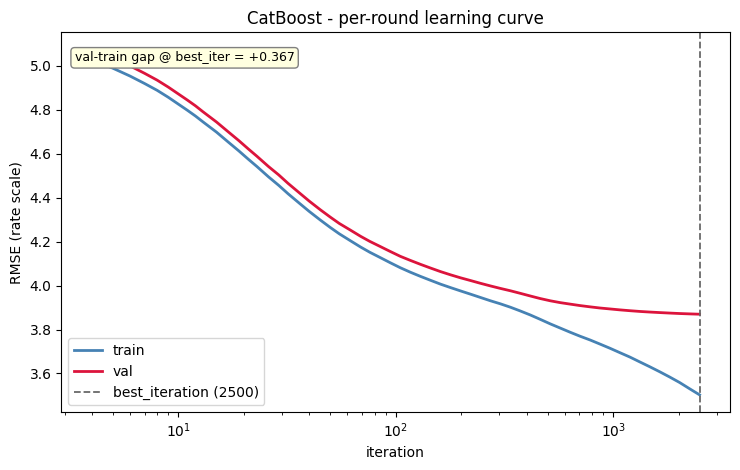

In [39]:
ev = explain_model.get_evals_result()
trc = np.array(ev['learn']['RMSE'])
vac = np.array(ev['validation']['RMSE'])
best_pos = int(np.argmin(vac))


def _sample_idx(n):
    s = np.unique(np.round(np.geomspace(5, n, 60)).astype(int)) - 1
    return s[s < n]


si = _sample_idx(len(vac))
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(si, trc[si], color='steelblue', label='train', linewidth=2)
ax.plot(si, vac[si], color='crimson', label='val', linewidth=2)
ax.axvline(best_pos, color='dimgrey', linestyle='--', linewidth=1.3,
           label='best_iteration (%d)' % (best_pos + 1))
ax.set_xscale('log')
ax.set_xlabel('iteration')
ax.set_ylabel('RMSE (rate scale)')
ax.set_title('CatBoost - per-round learning curve')
ax.legend()
gap_best = float(vac[best_pos] - trc[best_pos])
ax.text(0.02, 0.95, 'val-train gap @ best_iter = %+.3f' % gap_best,
        transform=ax.transAxes, ha='left', va='top', fontsize=9,
        bbox=dict(facecolor='lightyellow', edgecolor='grey', boxstyle='round'))
plt.tight_layout()
plt.savefig(OUT_DIR / 'catboost_diag_learning_curve.png', dpi=120, bbox_inches='tight')
plt.show()


## Plot 2 — sklearn `learning_curve` over training-set sizes

For a few training-set fractions we refit a smaller CatBoost and record train + CV RMSE.
Tells us whether more data would still help.

Computing sklearn learning_curve on CatBoost over training-set size...
  done in 385s


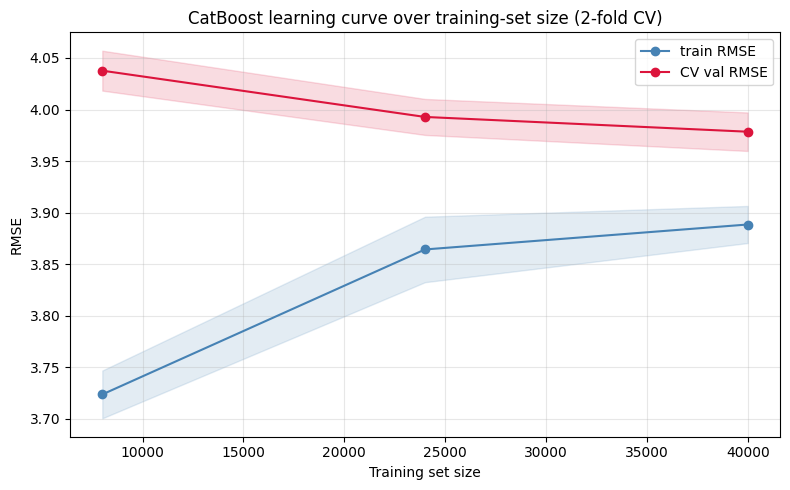


CV val RMSE slope between last two points: -0.000001 per row
  -> CV RMSE flat - capacity-saturated at this depth/iterations.


In [40]:
from sklearn.base import BaseEstimator, RegressorMixin

LC_SIZE_ITERS = 300
LC_SIZE_FRACTIONS = 3
LC_SIZE_CV = 2


class CatBoostFitShim(RegressorMixin, BaseEstimator):
    def __init__(self, cat_idx=None, columns=None, iterations=300,
                 learning_rate=0.03, depth=7, l2_leaf_reg=5.0,
                 loss_function='RMSE', eval_metric='RMSE'):
        self.cat_idx = cat_idx
        self.columns = columns
        self.iterations = iterations
        self.learning_rate = learning_rate
        self.depth = depth
        self.l2_leaf_reg = l2_leaf_reg
        self.loss_function = loss_function
        self.eval_metric = eval_metric

    def fit(self, X, y):
        self.model_ = CatBoostRegressor(
            iterations=self.iterations, learning_rate=self.learning_rate,
            depth=self.depth, l2_leaf_reg=self.l2_leaf_reg,
            loss_function=self.loss_function, eval_metric=self.eval_metric,
            random_seed=RANDOM_STATE, verbose=0, allow_writing_files=False)
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=list(self.columns))
        else:
            X = X.copy()
        for i in self.cat_idx:
            c = X.columns[i]
            X[c] = X[c].astype('string').fillna('Missing')
        self.feat_cols_ = X.columns.tolist()
        self.model_.fit(X, y, cat_features=list(self.cat_idx), verbose=False)
        return self

    def predict(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.feat_cols_)
        else:
            X = X.copy()
        for i in self.cat_idx:
            c = X.columns[i]
            X[c] = X[c].astype('string').fillna('Missing')
        return self.model_.predict(X)

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.estimator_type = 'regressor'
        try:
            from sklearn.utils._tags import RegressorTags
            tags.regressor_tags = RegressorTags()
        except Exception:
            pass
        return tags


print('Computing sklearn learning_curve on CatBoost over training-set size...')
t = time()
shim_lc = CatBoostFitShim(cat_idx=cat_idx_full, columns=Xtr_cb_full.columns,
                          iterations=LC_SIZE_ITERS,
                          learning_rate=CB_PARAMS.get('learning_rate', 0.03),
                          depth=CB_PARAMS.get('depth', 7),
                          l2_leaf_reg=CB_PARAMS.get('l2_leaf_reg', 5.0),
                          loss_function='RMSE', eval_metric='RMSE')
train_sizes_abs, train_scores, val_scores = learning_curve(
    shim_lc, Xtr_cb_full, y_train,
    train_sizes=np.linspace(0.2, 1.0, LC_SIZE_FRACTIONS),
    cv=LC_SIZE_CV, scoring='neg_root_mean_squared_error', n_jobs=1,
    random_state=RANDOM_STATE,
)
print('  done in %.0fs' % (time() - t))

train_rmse_mean = -train_scores.mean(axis=1); train_rmse_std = train_scores.std(axis=1)
val_rmse_mean = -val_scores.mean(axis=1); val_rmse_std = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes_abs, train_rmse_mean, 'o-', color='steelblue', label='train RMSE')
plt.fill_between(train_sizes_abs, train_rmse_mean - train_rmse_std, train_rmse_mean + train_rmse_std, color='steelblue', alpha=0.15)
plt.plot(train_sizes_abs, val_rmse_mean, 'o-', color='crimson', label='CV val RMSE')
plt.fill_between(train_sizes_abs, val_rmse_mean - val_rmse_std, val_rmse_mean + val_rmse_std, color='crimson', alpha=0.15)
plt.xlabel('Training set size'); plt.ylabel('RMSE')
plt.title('CatBoost learning curve over training-set size (%d-fold CV)' % LC_SIZE_CV)
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(OUT_DIR / 'catboost_diag_learning_curve_size.png', dpi=120, bbox_inches='tight')
plt.show()

slope = (val_rmse_mean[-1] - val_rmse_mean[-2]) / (train_sizes_abs[-1] - train_sizes_abs[-2])
print()
print('CV val RMSE slope between last two points: %.6f per row' % slope)
if slope < -1e-5:
    print('  -> CV RMSE still falling - more data would help.')
elif slope > 1e-5:
    print('  -> CV RMSE rising - capacity-limited, more data will not help.')
else:
    print('  -> CV RMSE flat - capacity-saturated at this depth/iterations.')


## Plot 3 — OOF-vs-val residual distribution overlay

Honest out-of-fold predictions on the 80% train fold via a live K-fold CatBoost (target
encoding refit inside each fold). If OOF and val residual distributions match,
generalisation is stable and the held-out RMSE is a trustworthy estimate.

In [41]:
OOF_CB_ITERS = 1500

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
oof_pred = np.zeros(len(X_train))
t = time()
for fold_id, (tr_i, va_i) in enumerate(kf.split(X_train)):
    Xtr_f, Xva_f = X_train.iloc[tr_i], X_train.iloc[va_i]
    ytr_f, yva_f = y_train[tr_i], y_train[va_i]
    Xtr_f_te, Xva_f_te, _ = add_target_encodings(Xtr_f, ytr_f, Xva_f, None)
    Xtr_f_cb, cidx_f = to_catboost_pool(Xtr_f_te)
    Xva_f_cb, _ = to_catboost_pool(Xva_f_te)
    m = CatBoostRegressor(**CB_PARAMS, iterations=OOF_CB_ITERS,
                          loss_function='RMSE', eval_metric='RMSE',
                          random_seed=RANDOM_STATE, verbose=0,
                          allow_writing_files=False, early_stopping_rounds=100)
    m.fit(Xtr_f_cb, ytr_f, cat_features=cidx_f, eval_set=(Xva_f_cb, yva_f), verbose=False)
    oof_pred[va_i] = m.predict(Xva_f_cb)
    print('  fold %d/%d  OOF RMSE=%.4f  (%.0fs)' % (
        fold_id + 1, N_FOLDS,
        np.sqrt(mean_squared_error(yva_f, oof_pred[va_i])), time() - t), flush=True)

oof_rmse = float(np.sqrt(mean_squared_error(y_train, oof_pred)))
print('Overall OOF RMSE: %.4f   (val RMSE: %.4f)' % (oof_rmse, val_rmse))


  fold 1/5  OOF RMSE=3.8522  (378s)
  fold 2/5  OOF RMSE=3.9176  (774s)
  fold 3/5  OOF RMSE=3.8819  (1132s)
  fold 4/5  OOF RMSE=3.8585  (1475s)
  fold 5/5  OOF RMSE=3.8481  (1829s)
Overall OOF RMSE: 3.8718   (val RMSE: 3.8698)


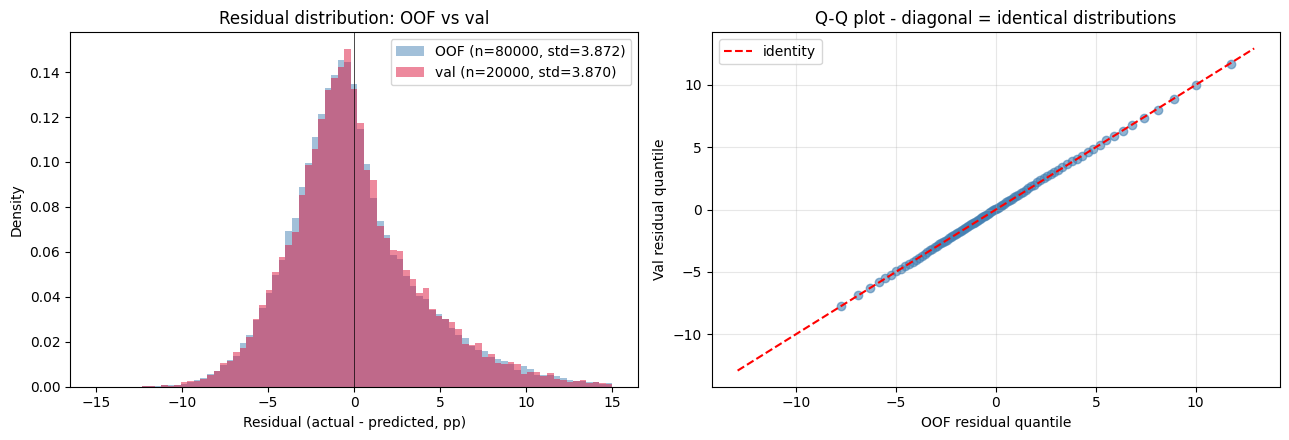


|std(OOF) - std(val)| = 0.0023
  -> Distributions match closely. Cross-fold generalisation looks healthy.


In [42]:
resid_oof = y_train - oof_pred
resid_val = y_val   - val_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
bins = np.linspace(-15, 15, 80)
axes[0].hist(resid_oof, bins=bins, alpha=0.5, color='steelblue', density=True,
             label='OOF (n=%d, std=%.3f)' % (len(resid_oof), resid_oof.std()))
axes[0].hist(resid_val, bins=bins, alpha=0.5, color='crimson', density=True,
             label='val (n=%d, std=%.3f)' % (len(resid_val), resid_val.std()))
axes[0].axvline(0, color='black', linewidth=0.5)
axes[0].set_xlabel('Residual (actual - predicted, pp)')
axes[0].set_ylabel('Density')
axes[0].set_title('Residual distribution: OOF vs val')
axes[0].legend()

oof_q = np.quantile(resid_oof, np.linspace(0.01, 0.99, 100))
val_q = np.quantile(resid_val, np.linspace(0.01, 0.99, 100))
axes[1].scatter(oof_q, val_q, alpha=0.6, color='steelblue')
lim = max(abs(oof_q).max(), abs(val_q).max()) * 1.1
axes[1].plot([-lim, lim], [-lim, lim], 'r--', label='identity')
axes[1].set_xlabel('OOF residual quantile')
axes[1].set_ylabel('Val residual quantile')
axes[1].set_title('Q-Q plot - diagonal = identical distributions')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'catboost_diag_resid_overlay.png', dpi=120, bbox_inches='tight')
plt.show()

ks_diff = abs(np.std(resid_oof) - np.std(resid_val))
print()
print('|std(OOF) - std(val)| = %.4f' % ks_diff)
if ks_diff < 0.1:
    print('  -> Distributions match closely. Cross-fold generalisation looks healthy.')
elif ks_diff < 0.3:
    print('  -> Mild divergence. Worth checking on a second seed.')
else:
    print('  -> Significant divergence - OOF and val tell different stories. Investigate.')


---
# Part 3 — Explainability (run live, W2 style)

Global (permutation, gain, SHAP) -> local (PDP, ICE, waterfall, LIME) -> cross-split SHAP.
All explanations use the single CatBoost (`explain_model`) trained in Part 1.

In [43]:
PERM_N_REPEATS = 3
SHAP_SAMPLE_SIZE = 800
SHAP_SPLIT_SAMPLE = 500

explain_val_rmse = float(np.sqrt(mean_squared_error(y_val, explain_model.predict(Xval_cb_full))))
print('Explainability CB val_RMSE: %.4f  (trees: %d)' % (explain_val_rmse, explain_model.tree_count_))


Explainability CB val_RMSE: 3.8698  (trees: 2500)


## 11. Permutation importance (validation set)

Computing permutation importance (n_repeats=3)...
  done in 32s


,feature,perm_mean,perm_std
0,fico,0.298480,0.009570
1,fico_band,0.242788,0.005204
2,term_x_dti,0.150182,0.002073
3,loan_amnt,0.146853,0.001226
4,purpose,0.110315,0.003093
5,mths_since_rcnt_il,0.098890,0.000990
6,fico_x_term,0.090239,0.005678
7,all_util,0.064271,0.001298
8,term_months,0.059077,0.002447
9,application_type,0.058949,0.001311


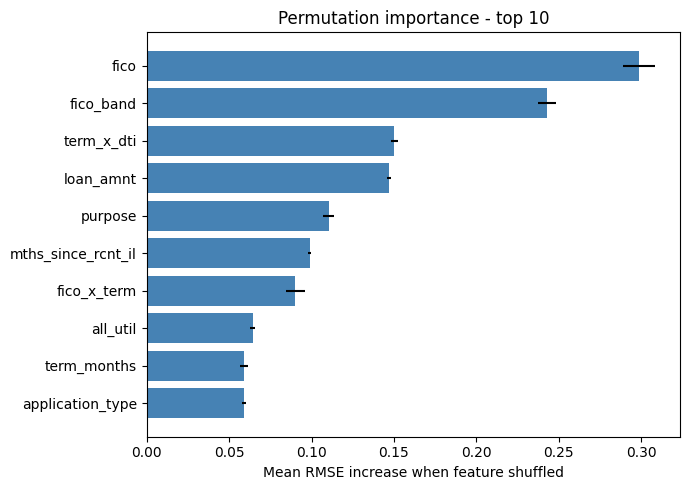

In [44]:
print('Computing permutation importance (n_repeats=%d)...' % PERM_N_REPEATS)
t = time()
rng = np.random.default_rng(RANDOM_STATE)
baseline_rmse = float(np.sqrt(mean_squared_error(y_val, explain_model.predict(Xval_cb_full))))
perm_records = []
for col in Xval_cb_full.columns:
    drops = []
    for r in range(PERM_N_REPEATS):
        Xp = Xval_cb_full.copy()
        Xp[col] = Xp[col].sample(frac=1.0, random_state=int(rng.integers(0, 1_000_000))).values
        rmse_perm = float(np.sqrt(mean_squared_error(y_val, explain_model.predict(Xp))))
        drops.append(rmse_perm - baseline_rmse)
    perm_records.append({'feature': col, 'perm_mean': float(np.mean(drops)), 'perm_std': float(np.std(drops))})
perm_df = pd.DataFrame(perm_records).sort_values('perm_mean', ascending=False).reset_index(drop=True)
print('  done in %.0fs' % (time() - t))
display(perm_df.head(15))

plt.figure(figsize=(7, 5))
top10 = perm_df.head(10)
plt.barh(top10['feature'][::-1], top10['perm_mean'][::-1], xerr=top10['perm_std'][::-1], color='steelblue')
plt.xlabel('Mean RMSE increase when feature shuffled')
plt.title('Permutation importance - top 10')
plt.tight_layout()
plt.savefig(OUT_DIR / 'catboost_perm_top10.png', dpi=120, bbox_inches='tight')
plt.show()
perm_df.to_csv(OUT_DIR / 'catboost_perm_importance.csv', index=False)


## 12. CatBoost native gain importance

,feature,gain,gain_share
0,fico,10.568493,0.105685
1,fico_band,10.051592,0.100516
2,term_x_dti,5.874811,0.058748
3,loan_amnt,4.604934,0.046049
4,purpose,4.065898,0.040659
5,mths_since_rcnt_il,3.947788,0.039478
6,all_util,3.807588,0.038076
7,fico_x_term,3.763482,0.037635
8,term_months,2.623015,0.026230
9,revol_bal,2.211840,0.022118


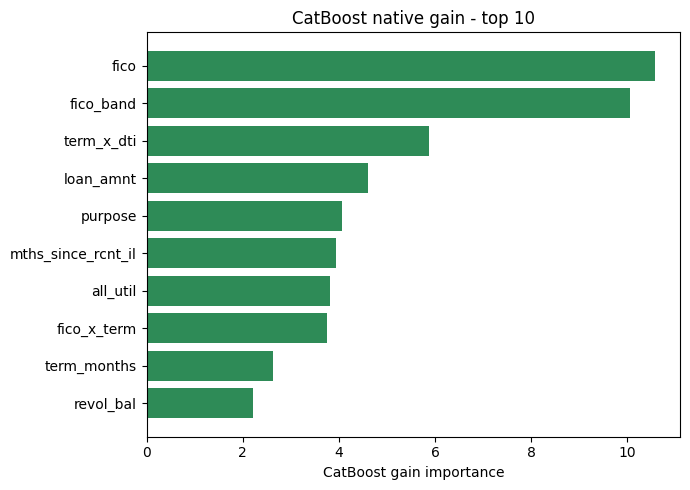

In [45]:
native_imp = pd.DataFrame({
    'feature': Xtr_cb_full.columns,
    'gain': explain_model.get_feature_importance(),
}).sort_values('gain', ascending=False).reset_index(drop=True)
native_imp['gain_share'] = native_imp['gain'] / native_imp['gain'].sum()
display(native_imp.head(15))

plt.figure(figsize=(7, 5))
top10 = native_imp.head(10)
plt.barh(top10['feature'][::-1], top10['gain'][::-1], color='seagreen')
plt.xlabel('CatBoost gain importance')
plt.title('CatBoost native gain - top 10')
plt.tight_layout()
plt.savefig(OUT_DIR / 'catboost_cb_gain_top10.png', dpi=120, bbox_inches='tight')
plt.show()
native_imp.to_csv(OUT_DIR / 'catboost_cb_gain.csv', index=False)


## 13. SHAP — summary and dependence on top features

Computing native CatBoost SHAP on val set...


SHAP shape: (800, 67)  expected: 12.930  (5s)


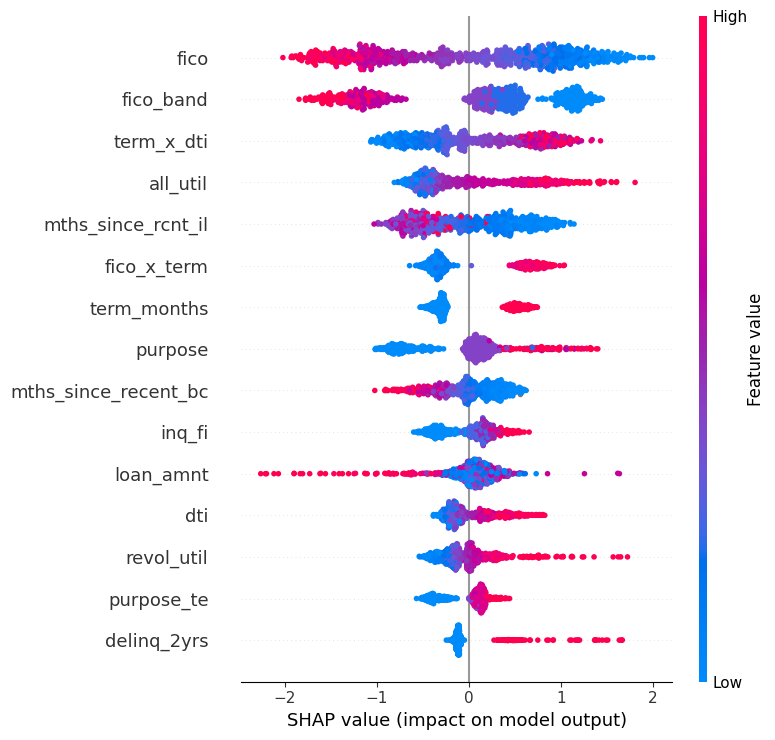

In [46]:
import shap


def cb_to_numeric(df_cb):
    out = df_cb.copy()
    for i in cat_idx_full:
        col = out.columns[i]
        codes, _ = pd.factorize(out[col].astype('string').fillna('Missing'))
        out[col] = codes.astype('int64')
    return out


shap_sample_size = min(SHAP_SAMPLE_SIZE, len(Xval_cb_full))
shap_idx = np.random.default_rng(RANDOM_STATE).choice(len(Xval_cb_full), size=shap_sample_size, replace=False)
Xval_shap_sample = Xval_cb_full.iloc[shap_idx].reset_index(drop=True)

print('Computing native CatBoost SHAP on val set...')
t = time()
pool_val = Pool(Xval_shap_sample, cat_features=cat_idx_full)
shap_with_expected = explain_model.get_feature_importance(pool_val, type='ShapValues')
expected_value = float(shap_with_expected[0, -1])
shap_values_val = shap_with_expected[:, :-1]
print('SHAP shape: %s  expected: %.3f  (%.0fs)' % (str(shap_values_val.shape), expected_value, time() - t))

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values_val, cb_to_numeric(Xval_shap_sample),
                  feature_names=list(Xval_shap_sample.columns), max_display=15, show=False)
plt.tight_layout()
plt.savefig(OUT_DIR / 'catboost_shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()


Top 5 by mean |SHAP|: ['fico', 'fico_band', 'term_x_dti', 'all_util', 'mths_since_rcnt_il']


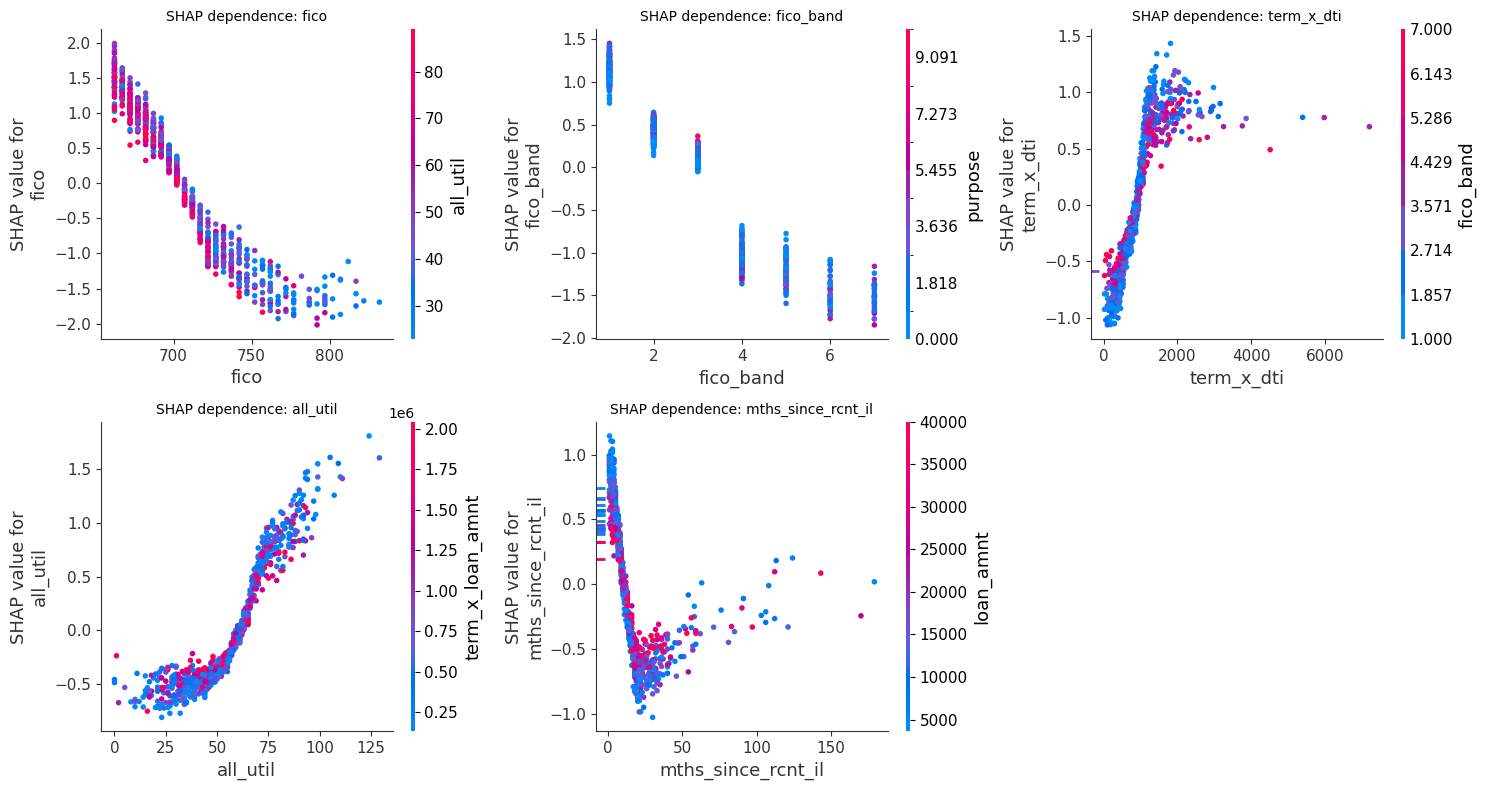

In [47]:
mean_abs_shap = np.abs(shap_values_val).mean(axis=0)
shap_ranking = pd.Series(mean_abs_shap, index=Xval_shap_sample.columns).sort_values(ascending=False)
top5_shap = shap_ranking.head(5).index.tolist()
print('Top 5 by mean |SHAP|:', top5_shap)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
Xval_shap_numeric_sample = cb_to_numeric(Xval_shap_sample)
for i, feat in enumerate(top5_shap):
    shap.dependence_plot(feat, shap_values_val, Xval_shap_numeric_sample,
                         feature_names=list(Xval_shap_sample.columns),
                         ax=axes[i], show=False, interaction_index='auto')
    axes[i].set_title('SHAP dependence: ' + feat, fontsize=10)
axes[-1].axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / 'catboost_shap_dependence_top5.png', dpi=120, bbox_inches='tight')
plt.show()


## 14. Partial dependence and ICE — top numeric features

PDP features: ['fico', 'fico_band', 'term_x_dti']


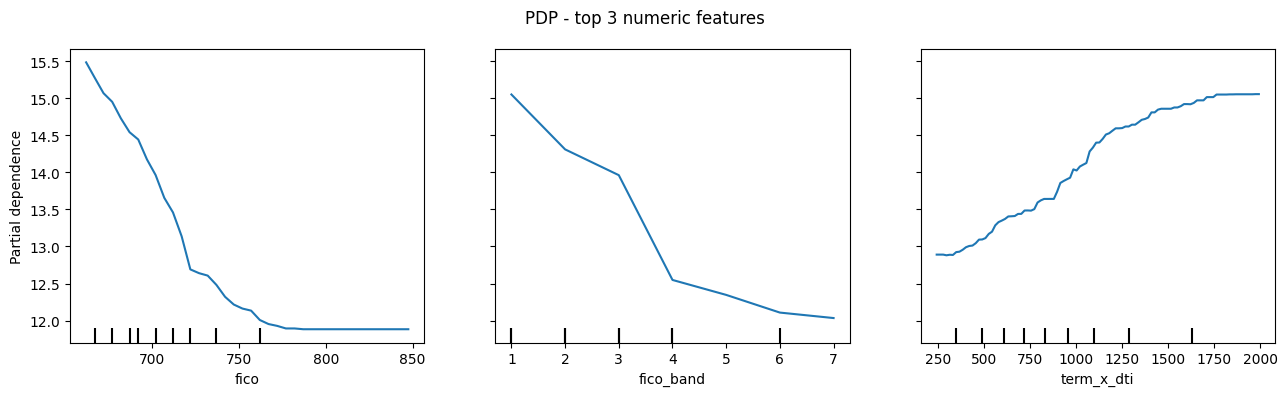

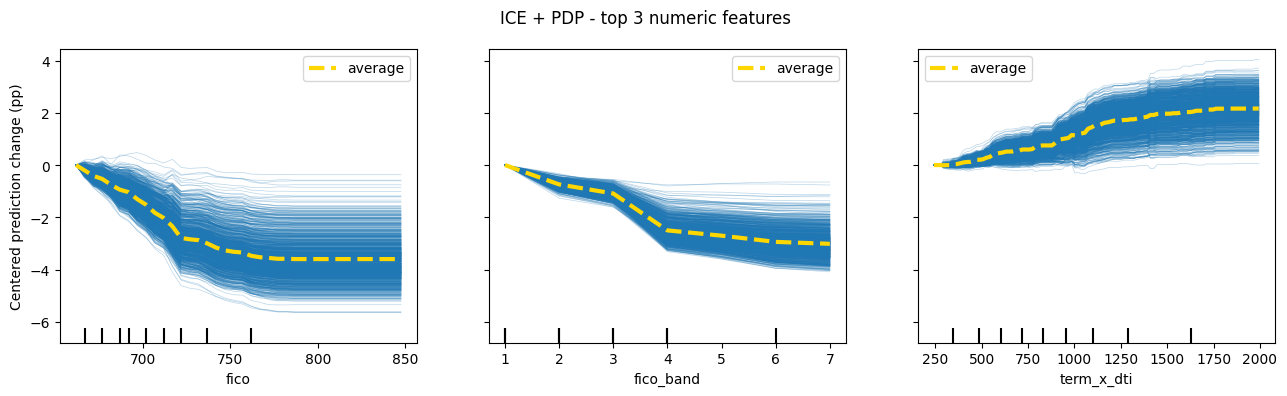

In [48]:
from sklearn.inspection import PartialDependenceDisplay


class CatBoostShim(RegressorMixin, BaseEstimator):
    def __init__(self, model, columns, cat_idx):
        self.model = model
        self.columns = list(columns)
        self.cat_idx = list(cat_idx)
        self.n_features_in_ = len(self.columns)
        self.feature_names_in_ = np.array(self.columns, dtype=object)
        self.is_fitted_ = True

    def __sklearn_is_fitted__(self):
        return True

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.estimator_type = 'regressor'
        try:
            from sklearn.utils._tags import RegressorTags
            tags.regressor_tags = RegressorTags()
        except Exception:
            pass
        return tags

    def fit(self, X, y=None):
        return self

    def predict(self, X):
        df = pd.DataFrame(X, columns=self.columns)
        for i in self.cat_idx:
            c = self.columns[i]
            df[c] = df[c].astype('string').fillna('Missing')
        for j, c in enumerate(self.columns):
            if j not in self.cat_idx:
                df[c] = pd.to_numeric(df[c], errors='coerce').astype('float64')
        return self.model.predict(df)


shim_pdp = CatBoostShim(explain_model, Xval_cb_full.columns, cat_idx_full)
Xtr_pdp_numeric = cb_to_numeric(Xtr_cb_full).values
numeric_cols_for_pdp = [c for j, c in enumerate(Xtr_cb_full.columns) if j not in cat_idx_full]
top3_perm_numeric = [f for f in perm_df['feature'] if f in numeric_cols_for_pdp][:3]
print('PDP features:', top3_perm_numeric)

fig, ax = plt.subplots(figsize=(13, 4))
PartialDependenceDisplay.from_estimator(
    shim_pdp, Xtr_pdp_numeric,
    features=[list(Xtr_cb_full.columns).index(f) for f in top3_perm_numeric],
    feature_names=list(Xtr_cb_full.columns), ax=ax, kind='average')
plt.suptitle('PDP - top 3 numeric features')
plt.tight_layout()
plt.savefig(OUT_DIR / 'catboost_pdp_top3.png', dpi=120, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
display_ice = PartialDependenceDisplay.from_estimator(
    shim_pdp, Xtr_pdp_numeric,
    features=[list(Xtr_cb_full.columns).index(f) for f in top3_perm_numeric],
    feature_names=list(Xtr_cb_full.columns), kind='both', centered=True, ax=ax,
    pd_line_kw={'color': 'gold', 'linewidth': 3})
display_ice.axes_[0, 0].set_ylabel('Centered prediction change (pp)')
plt.suptitle('ICE + PDP - top 3 numeric features')
plt.tight_layout()
plt.savefig(OUT_DIR / 'catboost_ice_top3.png', dpi=120, bbox_inches='tight')
plt.show()


## 15. Representative rows — SHAP waterfall and LIME

Representative rows:
  low rate (5th pct)     idx=6529  predicted=7.39%  actual=7.02%
  median rate            idx=16259  predicted=12.84%  actual=7.02%
  high rate (95th pct)   idx=9003  predicted=18.97%  actual=20.55%


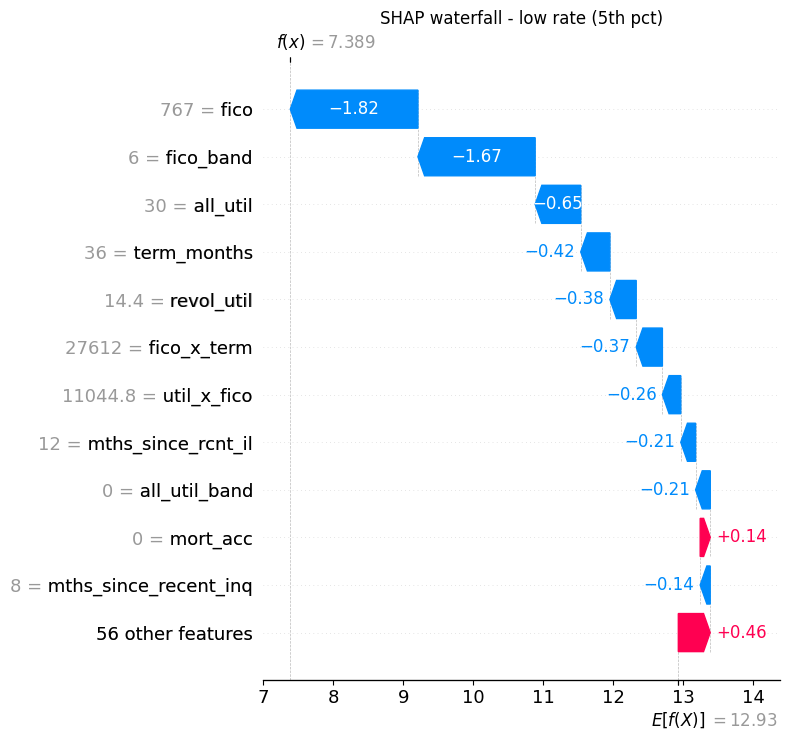

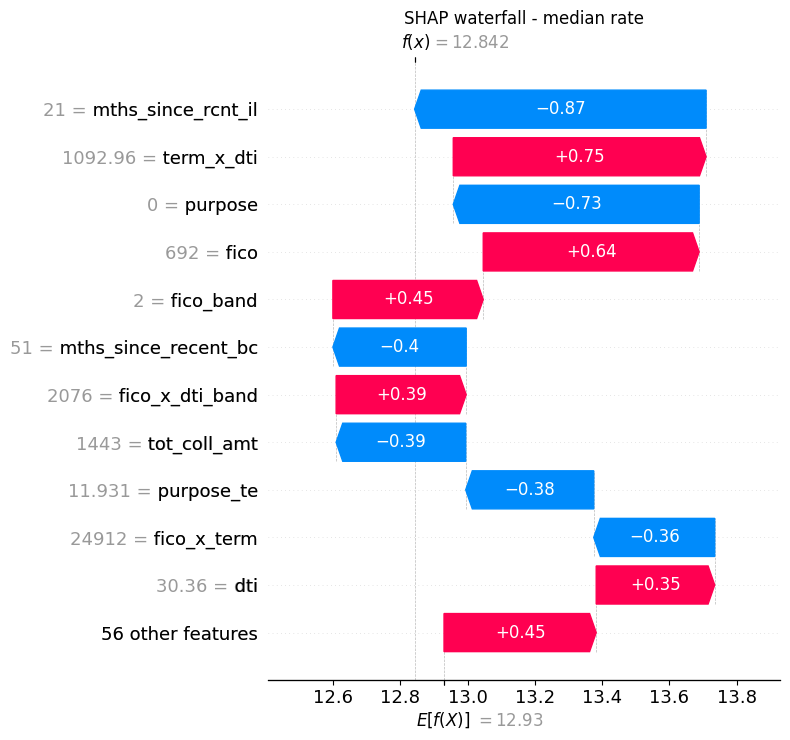

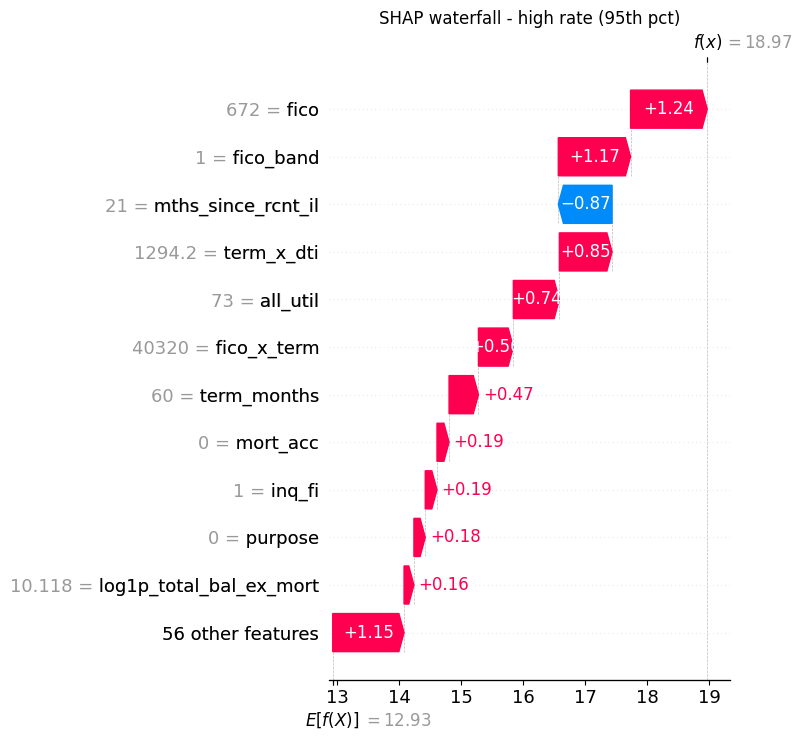

In [49]:
val_preds = val_pred
order = np.argsort(val_preds)
rep_indices = {
    'low rate (5th pct)':   int(order[int(0.05 * len(order))]),
    'median rate':          int(order[len(order) // 2]),
    'high rate (95th pct)': int(order[int(0.95 * len(order))]),
}
print('Representative rows:')
for label, idx in rep_indices.items():
    print('  %-22s idx=%d  predicted=%.2f%%  actual=%.2f%%' % (label, idx, val_preds[idx], y_val[idx]))

for label, idx in rep_indices.items():
    instance_row = Xval_cb_full.iloc[[idx]].reset_index(drop=True)
    pool_inst = Pool(instance_row, cat_features=cat_idx_full)
    shap_with_exp = explain_model.get_feature_importance(pool_inst, type='ShapValues')
    expected = float(shap_with_exp[0, -1])
    shap_values_inst = shap_with_exp[:, :-1]
    instance_dense = cb_to_numeric(instance_row).iloc[0].values
    plt.figure()
    shap.plots.waterfall(
        shap.Explanation(values=shap_values_inst[0], base_values=expected,
                         data=instance_dense, feature_names=list(instance_row.columns)),
        max_display=12, show=False)
    plt.title('SHAP waterfall - ' + label)
    plt.tight_layout()
    plt.savefig(OUT_DIR / ('catboost_shap_waterfall_' + label.split()[0] + '.png'), dpi=120, bbox_inches='tight')
    plt.show()



--- LIME: low rate (5th pct)  (predicted 7.39%, actual 7.02%) ---


,feature,weight
0,fico,-1.080165
1,emp_title=7,-1.073741
2,fico_band,-0.891780
3,all_util,0.438668
4,term_months,0.363300
5,zip3=489,-0.317720
6,revol_util,0.281854
7,mo_sin_old_rev_tl_op,-0.195802
8,purpose=1,0.172815
9,util_x_fico,0.153999


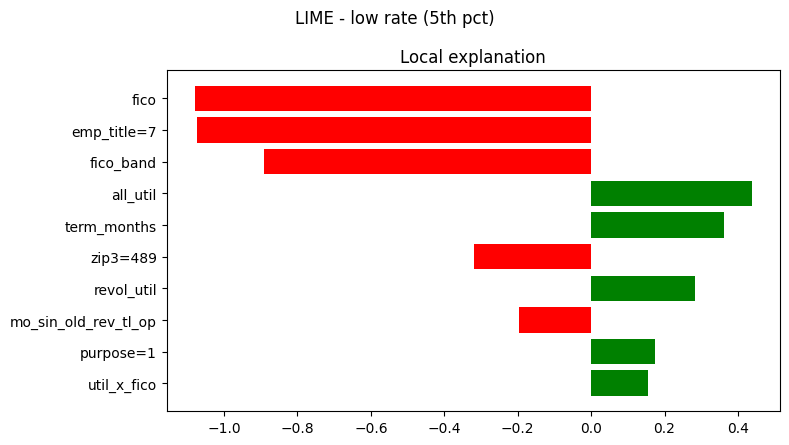


--- LIME: median rate  (predicted 12.84%, actual 7.02%) ---


,feature,weight
0,fico,-1.012996
1,purpose=0,-0.964140
2,fico_band,-0.892348
3,mths_since_recent_bc,-0.431216
4,fico_x_term,0.405498
5,term_months,0.341910
6,mo_sin_old_rev_tl_op,-0.259583
7,purpose_te,0.202455
8,verification_status=0,-0.180921
9,collections_12_mths_ex_med,-0.047268


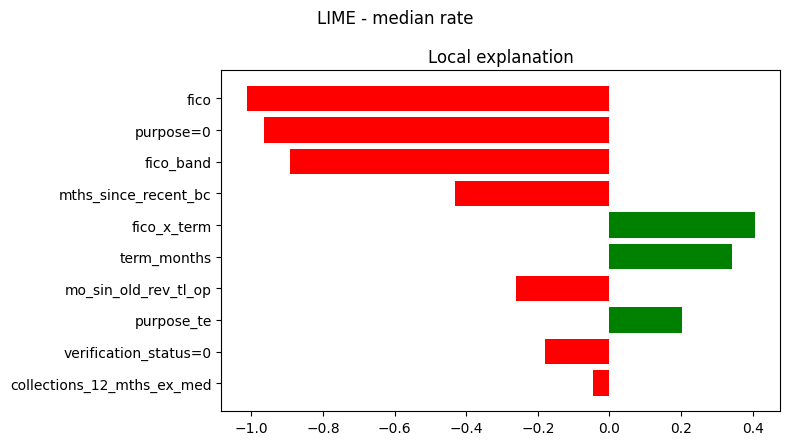


--- LIME: high rate (95th pct)  (predicted 18.97%, actual 20.55%) ---


,feature,weight
0,fico,-1.048320
1,fico_band,-0.892648
2,term_x_dti,0.627651
3,all_util,0.407216
4,fico_x_term,0.391758
5,term_months,0.361988
6,revol_util,0.330102
7,home_ownership=0,0.193334
8,purpose=1,0.150575
9,mths_since_recent_inq,-0.141423


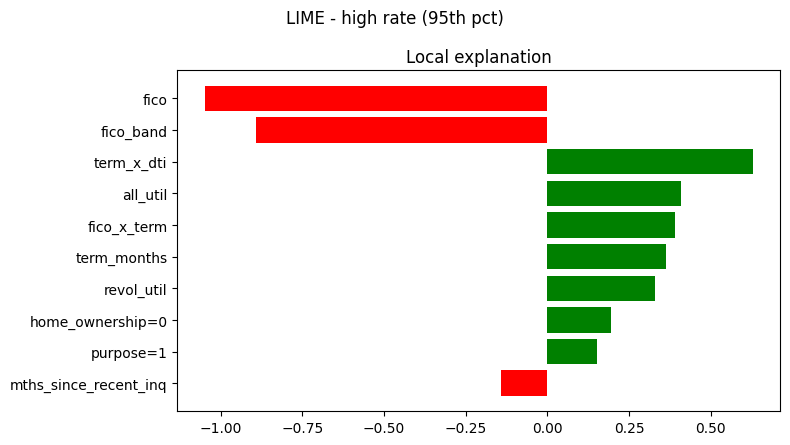

In [50]:
import lime
import lime.lime_tabular

cat_code_maps = {}
cat_train_arrays = {}
for i in cat_idx_full:
    col = Xtr_cb_full.columns[i]
    series_str = Xtr_cb_full[col].astype('string').fillna('Missing')
    codes, uniques = pd.factorize(series_str)
    cat_code_maps[col] = {idx: val for idx, val in enumerate(uniques)}
    cat_train_arrays[col] = codes

Xtr_lime = Xtr_cb_full.copy()
for i in cat_idx_full:
    col = Xtr_cb_full.columns[i]
    Xtr_lime[col] = cat_train_arrays[col]
for j, c in enumerate(Xtr_lime.columns):
    if j not in cat_idx_full:
        Xtr_lime[c] = pd.to_numeric(Xtr_lime[c], errors='coerce').astype('float64')
Xtr_lime_np = Xtr_lime.values.astype('float64')

lime_fill = np.nanmean(Xtr_lime_np, axis=0)
lime_fill = np.where(np.isnan(lime_fill), 0.0, lime_fill)
inds = np.where(np.isnan(Xtr_lime_np))
Xtr_lime_np[inds] = np.take(lime_fill, inds[1])

Xval_lime = Xval_cb_full.copy()
for i in cat_idx_full:
    col = Xval_cb_full.columns[i]
    series_str = Xval_cb_full[col].astype('string').fillna('Missing')
    inv = {v: k for k, v in cat_code_maps[col].items()}
    next_code = max(cat_code_maps[col].keys()) + 1 if cat_code_maps[col] else 0
    Xval_lime[col] = series_str.map(lambda v: inv.get(v, next_code)).astype('int64')
for j, c in enumerate(Xval_lime.columns):
    if j not in cat_idx_full:
        Xval_lime[c] = pd.to_numeric(Xval_lime[c], errors='coerce').astype('float64')
Xval_lime_np = Xval_lime.values.astype('float64')
inds = np.where(np.isnan(Xval_lime_np))
Xval_lime_np[inds] = np.take(lime_fill, inds[1])

lime_categorical_features = [list(Xtr_cb_full.columns).index(c)
                             for c in ALL_CAT_COLS if c in Xtr_cb_full.columns]
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=Xtr_lime_np,
    feature_names=list(Xtr_cb_full.columns),
    categorical_features=lime_categorical_features,
    mode='regression',
    random_state=RANDOM_STATE,
    discretize_continuous=False,
)


def cb_predict_numeric(X_np):
    df = pd.DataFrame(X_np, columns=Xtr_cb_full.columns)
    for i in cat_idx_full:
        col = Xtr_cb_full.columns[i]
        mapping = cat_code_maps[col]
        codes_int = df[col].round().astype('Int64')
        df[col] = codes_int.apply(lambda v: mapping.get(int(v), 'Missing') if pd.notna(v) else 'Missing').astype('string')
    for j, c in enumerate(df.columns):
        if j not in cat_idx_full:
            df[c] = pd.to_numeric(df[c], errors='coerce').astype('float64')
    return explain_model.predict(df)


for label, idx in rep_indices.items():
    instance_np = Xval_lime_np[idx]
    print()
    print('--- LIME: %s  (predicted %.2f%%, actual %.2f%%) ---' % (label, val_preds[idx], y_val[idx]))
    explanation = lime_explainer.explain_instance(instance_np, cb_predict_numeric, num_features=10)
    lime_rows = pd.DataFrame(explanation.as_list(), columns=['feature', 'weight'])
    display(lime_rows)
    fig = explanation.as_pyplot_figure()
    fig.set_size_inches(8, 4.5)
    fig.suptitle('LIME - ' + label)
    plt.tight_layout()
    fig.savefig(OUT_DIR / ('catboost_lime_' + label.split()[0] + '.png'), dpi=120, bbox_inches='tight')
    plt.show()


## 16. Cross-split SHAP — train vs validation vs test

Mean |SHAP| per feature on each split. The test column is included only when `LC_test.csv`
is present. Large train->test drift on a top feature is a distribution-shift warning.

,feature,mean_abs_train,mean_abs_val,mean_abs_test
0,fico,0.899,0.930,0.937
1,fico_band,0.781,0.822,0.824
2,term_x_dti,0.547,0.541,0.502
3,all_util,0.495,0.502,0.453
4,mths_since_rcnt_il,0.452,0.475,0.455
5,fico_x_term,0.456,0.451,0.429
6,term_months,0.394,0.388,0.378
7,purpose,0.397,0.376,0.378
8,mths_since_recent_bc,0.271,0.279,0.243
9,revol_util,0.244,0.244,0.210


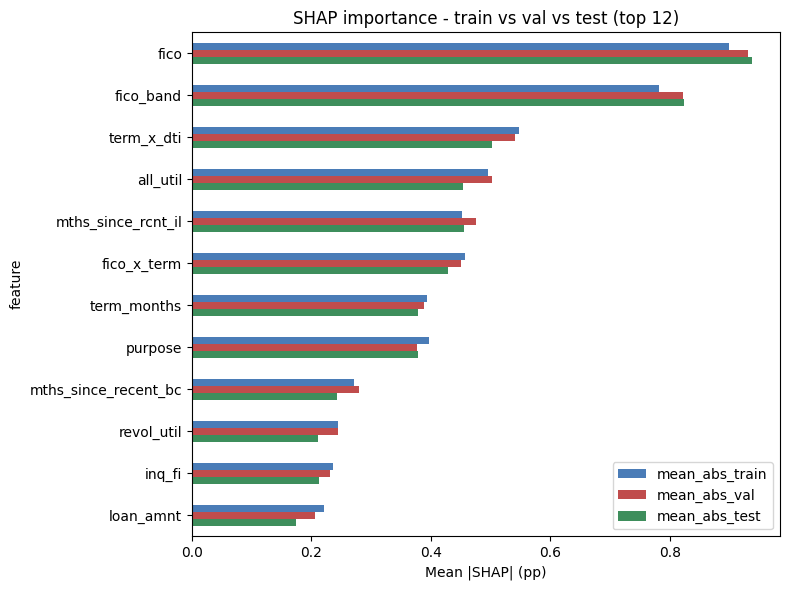

In [51]:
def _native_shap(df_subset):
    pool = Pool(df_subset, cat_features=cat_idx_full)
    arr = explain_model.get_feature_importance(pool, type='ShapValues')
    return arr[:, :-1]


SAMPLE = SHAP_SPLIT_SAMPLE
rng = np.random.default_rng(RANDOM_STATE)
oof_idx_sub = rng.choice(len(Xtr_cb_full), size=min(SAMPLE, len(Xtr_cb_full)), replace=False)
val_idx_sub = rng.choice(len(Xval_cb_full), size=min(SAMPLE, len(Xval_cb_full)), replace=False)
shap_train = _native_shap(Xtr_cb_full.iloc[oof_idx_sub].reset_index(drop=True))
shap_val   = _native_shap(Xval_cb_full.iloc[val_idx_sub].reset_index(drop=True))

cols = {
    'feature':        list(Xval_cb_full.columns),
    'mean_abs_train': np.abs(shap_train).mean(axis=0),
    'mean_abs_val':   np.abs(shap_val).mean(axis=0),
}
plot_cols = ['mean_abs_train', 'mean_abs_val']
plot_colors = ['#4A7CB7', '#C04C4C']
if HAS_TEST:
    test_idx_sub = rng.choice(len(Xte_cb_full), size=min(SAMPLE, len(Xte_cb_full)), replace=False)
    shap_test = _native_shap(Xte_cb_full.iloc[test_idx_sub].reset_index(drop=True))
    cols['mean_abs_test'] = np.abs(shap_test).mean(axis=0)
    plot_cols.append('mean_abs_test')
    plot_colors.append('#3E8E5C')

shap_compare = pd.DataFrame(cols).sort_values('mean_abs_val', ascending=False).reset_index(drop=True)
fmt = {c: '{:.3f}' for c in plot_cols}
display(shap_compare.head(15).style.format(fmt))
shap_compare.to_csv(OUT_DIR / 'catboost_shap_meanabs_by_split.csv', index=False)

top_feats = shap_compare.head(12)['feature'].tolist()
top_df = shap_compare.set_index('feature').loc[top_feats][plot_cols]
ax = top_df.plot(kind='barh', figsize=(8, 6), color=plot_colors)
ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP| (pp)')
ax.set_title('SHAP importance - train vs val' + (' vs test' if HAS_TEST else '') + ' (top 12)')
plt.tight_layout()
plt.savefig(OUT_DIR / 'catboost_shap_meanabs_by_split.png', dpi=120, bbox_inches='tight')
plt.show()


## 17. Summary

This standalone notebook is fully self-contained: it imports no project module and reads no
cached tuning JSON. It runs end-to-end on `true data/LC_train.csv` alone, and additionally
writes the test submission when `true data/LC_test.csv` is present.

**Outputs written to `final-submission-output/`:** the final predictions CSV
(`SAXA5.csv`, or `catboost_val_predictions.csv` in a train-only run),
`catboost_results.csv`, `catboost_residuals.png`, `catboost_diag_*.png`, `catboost_perm_*`,
`catboost_cb_gain_*`, `catboost_shap_*`, `catboost_pdp_top3.png`, `catboost_ice_top3.png`,
and `catboost_lime_*.png`.
